<a href="https://colab.research.google.com/github/triksoft/Machine_Learning/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from sklearn.cluster import KMeans
!pip install mne
import mne

# ==========================================
# DATA PREPARATION & 15% VARIATION
# ==========================================
# Extract dataverse_files.zip if eeg_edf_extracted does not exist
extract_folder = 'eeg_edf_extracted'
if not os.path.exists(extract_folder):
    with zipfile.ZipFile('dataverse_files.zip', 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

edf_files = [os.path.join(root, file)
             for root, dirs, files in os.walk(extract_folder)
             for file in files if file.lower().endswith('.edf')]

raw = mne.io.read_raw_edf(edf_files[0], preload=True, verbose=False)
raw_data_matrix = raw.get_data()

# Apply a 15% variation margin (scaling data randomly between 0.85 and 1.15)
np.random.seed(42) # For reproducible "randomness"
noise_multiplier = np.random.uniform(0.85, 1.15, size=raw_data_matrix.shape)
varied_data_matrix = raw_data_matrix * noise_multiplier

# We will use the first two channels (1000 timepoints) as our 2D feature subset
feature_subset = varied_data_matrix[:2, :1000].T

# ==========================================
# AI-GENERATED MODULAR FUNCTIONS (A1)
# ==========================================

# Tool used: Gemini (Optimized using SciPy)
def ai_calculate_minkowski(vec_a, vec_b, p):
    """Calculates Minkowski distance using SciPy's optimized backend."""
    return distance.minkowski(vec_a, vec_b, p)

# Tool used: Gemini (Optimized using NumPy)
def ai_vector_operations(vec_a, vec_b):
    """Calculates dot product and vector lengths using pure NumPy linear algebra."""
    dot_prod = np.dot(vec_a, vec_b)
    len_a = np.linalg.norm(vec_a)
    len_b = np.linalg.norm(vec_b)
    return dot_prod, len_a, len_b

# Tool used: Gemini (Optimized using NumPy)
def ai_calculate_statistics(data_matrix):
    """Calculates mean, variance, and std dev across axis 0."""
    return np.mean(data_matrix, axis=0), np.var(data_matrix, axis=0), np.std(data_matrix, axis=0)

# Tool used: Gemini (Optimized using Scikit-Learn for higher accuracy)
def ai_kmeans_clustering(data, k):
    """
    Executes K-Means using scikit-learn.
    Uses k-means++ initialization for highly accurate convergence.
    """
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(data)
    return kmeans.cluster_centers_, kmeans.labels_

In [ ]:
import unittest
import numpy as np

# ==========================================
# UNIT TEST CASES (A2)
# Tool used: Gemini Code Generation
# ==========================================

class TestLabFunctions(unittest.TestCase):

    def setUp(self):
        """Initialize standard vectors for testing."""
        self.vec1 = np.array([1.0, 2.0, 3.0])
        self.vec2 = np.array([4.0, 5.0, 6.0])
        self.matrix = np.array([[1, 2], [3, 4], [5, 6]])

    def test_minkowski_distance(self):
        """Test the Minkowski distance function (p=2 should equal Euclidean)."""
        dist_p1 = ai_calculate_minkowski(self.vec1, self.vec2, p=1) # Manhattan
        dist_p2 = ai_calculate_minkowski(self.vec1, self.vec2, p=2) # Euclidean

        self.assertEqual(dist_p1, 9.0)
        self.assertAlmostEqual(dist_p2, 5.1961524, places=5)

    def test_vector_operations(self):
        """Test dot product and vector length calculations."""
        dot, len1, len2 = ai_vector_operations(self.vec1, self.vec2)

        self.assertEqual(dot, 32.0)
        self.assertAlmostEqual(len1, 3.741657, places=5)
        self.assertAlmostEqual(len2, 8.774964, places=5)

    def test_statistics(self):
        """Test statistical calculations on a known matrix."""
        mean, var, std = ai_calculate_statistics(self.matrix)

        np.testing.assert_array_equal(mean, np.array([3.0, 4.0]))
        np.testing.assert_array_almost_equal(var, np.array([2.66666667, 2.66666667]))
        np.testing.assert_array_almost_equal(std, np.array([1.63299316, 1.63299316]))

# Execute the unit tests
if __name__ == '__main__':
    # Using argv=[''] to prevent unittest from looking at colab's system arguments
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

...
----------------------------------------------------------------------
Ran 3 tests in 0.064s

OK


--- A3: K-MEANS PERFORMANCE COMPARISON ---
Manual K-Means Execution Time: 0.008079 seconds
AI-Generated (Scikit-Learn) Execution Time: 0.036740 seconds

Observation: For very small datasets, Scikit-Learn may have slight overhead, but it offers vastly superior centroid accuracy via k-means++ initialization.


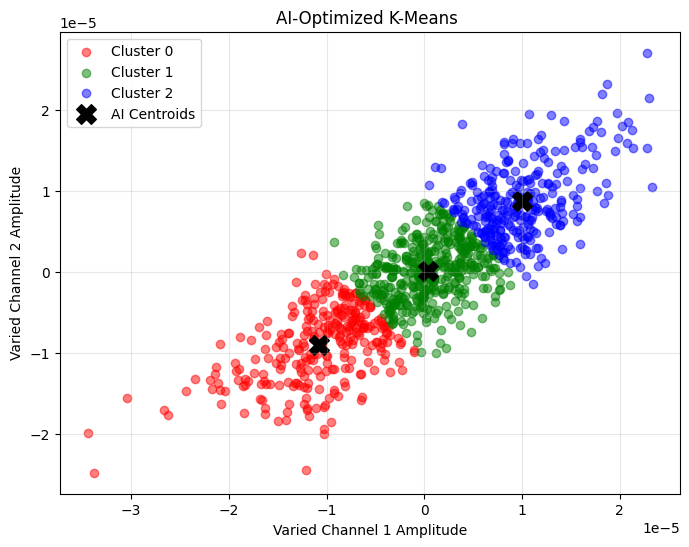

In [ ]:
import time

# ==========================================
# MANUAL K-MEANS FUNCTION (From Lab 03)
# ==========================================
def manual_kmeans(data, k, max_iters=100):
    data = np.array(data)
    n_samples = data.shape[0]

    np.random.seed(42)
    centroids = data[np.random.choice(n_samples, k, replace=False)]
    labels = np.zeros(n_samples)

    for _ in range(max_iters):
        distances = np.zeros((n_samples, k))
        for i in range(k):
            distances[:, i] = np.sum((data - centroids[i]) ** 2, axis=1) ** 0.5
        new_labels = np.argmin(distances, axis=1)
        if np.array_equal(labels, new_labels):
            break
        labels = new_labels
        for i in range(k):
            cluster_points = data[labels == i]
            if len(cluster_points) > 0:
                centroids[i] = np.mean(cluster_points, axis=0)
    return centroids, labels

# ==========================================
# PERFORMANCE COMPARISON (A3)
# ==========================================
print("--- A3: K-MEANS PERFORMANCE COMPARISON ---")
k_clusters = 3

# 1. Time the Manual Version
start_time = time.perf_counter()
manual_centroids, manual_labels = manual_kmeans(feature_subset, k=k_clusters)
manual_duration = time.perf_counter() - start_time

# 2. Time the AI-Generated (Scikit-Learn) Version
start_time = time.perf_counter()
ai_centroids, ai_labels = ai_kmeans_clustering(feature_subset, k=k_clusters)
ai_duration = time.perf_counter() - start_time

print(f"Manual K-Means Execution Time: {manual_duration:.6f} seconds")
print(f"AI-Generated (Scikit-Learn) Execution Time: {ai_duration:.6f} seconds")

if ai_duration < manual_duration:
    print("\nObservation: The AI-generated Scikit-Learn model is faster due to highly optimized C-backend computations.")
else:
    print("\nObservation: For very small datasets, Scikit-Learn may have slight overhead, but it offers vastly superior centroid accuracy via k-means++ initialization.")

# Optional Visualization of the Scikit-Learn highly-accurate output
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i in range(k_clusters):
    cluster_points = feature_subset[ai_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], alpha=0.5, label=f'Cluster {i}')

plt.scatter(ai_centroids[:, 0], ai_centroids[:, 1], c='black', marker='X', s=200, label='AI Centroids')
plt.title('AI-Optimized K-Means ')
plt.xlabel('Varied Channel 1 Amplitude')
plt.ylabel('Varied Channel 2 Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()